In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.impute import SimpleImputer
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder, FunctionTransformer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import r2_score, root_mean_squared_error


import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

# 1- Understanding the dataset

In [2]:
df_train = pd.read_csv('train.csv')
df_train.drop(columns=['Id'], inplace=True)

df_test = pd.read_csv('test.csv')
df_test_id = df_test['Id']
df_test.drop(columns=['Id'], inplace=True)

df_train.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
# From Data desciption, we can see that MSSubClass is categorical variable, so we will convert it to object type
df_train['MSSubClass'] = df_train['MSSubClass'].astype('object')
df_test['MSSubClass'] = df_test['MSSubClass'].astype('object')

In [4]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   object 
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   Alley          91 non-null     object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuil

In [5]:
df_train.describe().T

,count,mean,std,min,25%,50%,75%,max
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0
BsmtFinSF2,1460.0,46.549315,161.319273,0.0,0.00,0.0,0.00,1474.0
BsmtUnfSF,1460.0,567.240411,441.866955,0.0,223.00,477.5,808.00,2336.0


- We can detect from the mean and median that there is outlier in the SalePrice Column 

In [6]:
def get_null_count(df):
    null_count = df.isna().sum() / df.shape[0] * 100
    null_count = null_count[null_count > 0].sort_values(ascending=False)
    return null_count

print("Null Count in Train Set:")
get_null_count(df_train)

Null Count in Train Set:


PoolQC          99.520548
MiscFeature     96.301370
Alley           93.767123
Fence           80.753425
MasVnrType      59.726027
FireplaceQu     47.260274
LotFrontage     17.739726
GarageType       5.547945
GarageYrBlt      5.547945
GarageFinish     5.547945
GarageQual       5.547945
GarageCond       5.547945
BsmtFinType2     2.602740
BsmtExposure     2.602740
BsmtFinType1     2.534247
BsmtCond         2.534247
BsmtQual         2.534247
MasVnrArea       0.547945
Electrical       0.068493
dtype: float64

- Maybe not all the null values means that the value is null maybe it means that the row doesn't have the value(zero) 

In [7]:
# Null in test set
print("Null Count in Test Set:")
get_null_count(df_test)

Null Count in Test Set:


PoolQC          99.794380
MiscFeature     96.504455
Alley           92.666210
Fence           80.123372
MasVnrType      61.274846
FireplaceQu     50.034270
LotFrontage     15.558602
GarageCond       5.346127
GarageYrBlt      5.346127
GarageQual       5.346127
GarageFinish     5.346127
GarageType       5.209047
BsmtCond         3.084304
BsmtExposure     3.015764
BsmtQual         3.015764
BsmtFinType1     2.878684
BsmtFinType2     2.878684
MasVnrArea       1.028101
MSZoning         0.274160
BsmtFullBath     0.137080
BsmtHalfBath     0.137080
Functional       0.137080
Utilities        0.137080
GarageCars       0.068540
GarageArea       0.068540
TotalBsmtSF      0.068540
KitchenQual      0.068540
BsmtUnfSF        0.068540
BsmtFinSF2       0.068540
BsmtFinSF1       0.068540
Exterior2nd      0.068540
Exterior1st      0.068540
SaleType         0.068540
dtype: float64

In [8]:
df_train.duplicated().sum()

0

- We have no duplicates

In [9]:
numerical_features = df_train.select_dtypes("number").columns
categorical_features = df_train.select_dtypes("object").columns

In [10]:
print(f'Number of Categorical Features: {len(categorical_features)}')
for col in categorical_features:
    print(f"{col}: ")
    print(f"Unique Values: {df_train[col].nunique()}")
    print(f"Value Counts:\n{df_train[col].value_counts(ascending=False, dropna=False)[:5]}")
    print("-" * 50)

Number of Categorical Features: 44
MSSubClass: 
Unique Values: 15
Value Counts:
MSSubClass
20     536
60     299
50     144
120     87
30      69
Name: count, dtype: int64
--------------------------------------------------
MSZoning: 
Unique Values: 5
Value Counts:
MSZoning
RL         1151
RM          218
FV           65
RH           16
C (all)      10
Name: count, dtype: int64
--------------------------------------------------
Street: 
Unique Values: 2
Value Counts:
Street
Pave    1454
Grvl       6
Name: count, dtype: int64
--------------------------------------------------
Alley: 
Unique Values: 2
Value Counts:
Alley
NaN     1369
Grvl      50
Pave      41
Name: count, dtype: int64
--------------------------------------------------
LotShape: 
Unique Values: 4
Value Counts:
LotShape
Reg    925
IR1    484
IR2     41
IR3     10
Name: count, dtype: int64
--------------------------------------------------
LandContour: 
Unique Values: 4
Value Counts:
LandContour
Lvl    1311
Bnk      63
HLS  

- We can turn some categories into orders

### Investgating Nulls and Cleaning

In [11]:
for col in get_null_count(df_train).index:
    print(f"{col}: ")
    print(f"Unique Values: {df_train[col].nunique()}")
    print(f"Value Counts:\n{df_train[col].value_counts(ascending=False, dropna=False)}")
    print("-" * 50)

PoolQC: 
Unique Values: 3
Value Counts:
PoolQC
NaN    1453
Gd        3
Ex        2
Fa        2
Name: count, dtype: int64
--------------------------------------------------
MiscFeature: 
Unique Values: 4
Value Counts:
MiscFeature
NaN     1406
Shed      49
Gar2       2
Othr       2
TenC       1
Name: count, dtype: int64
--------------------------------------------------
Alley: 
Unique Values: 2
Value Counts:
Alley
NaN     1369
Grvl      50
Pave      41
Name: count, dtype: int64
--------------------------------------------------
Fence: 
Unique Values: 4
Value Counts:
Fence
NaN      1179
MnPrv     157
GdPrv      59
GdWo       54
MnWw       11
Name: count, dtype: int64
--------------------------------------------------
MasVnrType: 
Unique Values: 3
Value Counts:
MasVnrType
NaN        872
BrkFace    445
Stone      128
BrkCmn      15
Name: count, dtype: int64
--------------------------------------------------
FireplaceQu: 
Unique Values: 5
Value Counts:
FireplaceQu
NaN    690
Gd     380
TA   

In [12]:
df_train[df_train['MasVnrArea'].isna()][['MasVnrType', 'MasVnrArea']]

,MasVnrType,MasVnrArea
234,NaN,NaN
529,NaN,NaN
650,NaN,NaN
936,NaN,NaN
973,NaN,NaN
977,NaN,NaN
1243,NaN,NaN
1278,NaN,NaN


### After Investgating the null values we can see that:
- Electrical, LotFrontage need to be imputed when processing the data
- MasVnrArea should be replcaed with 0 because its null with the data that has none MasVnrType
- GarageYrBlt feature should be removed or replaced by another feature('GarageAge') depending on how well it would affect our target
- Every other NaN values represents that the row doesn't has the feature so we should fix this now

In [13]:
NONE_CAT = ['Alley', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
            'BsmtFinType2', 'FireplaceQu', 'GarageType', 'GarageFinish',
            'GarageQual', 'GarageCond', 'PoolQC', 'Fence', 'MiscFeature',
            'MasVnrType']

ZERO_NUM = ['MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
            'BsmtFullBath', 'BsmtHalfBath', 'GarageCars', 'GarageArea']

# Fill None and Zero
def fill_none(df):
    df = df.copy()
    df[NONE_CAT] = df[NONE_CAT].fillna('None')
    df[ZERO_NUM] = df[ZERO_NUM].fillna(0)
    return df


df_train = fill_none(df_train)
df_test = fill_none(df_test)

In [14]:
print("Null Count in Train Set after filling None and Zero:")
get_null_count(df_train)

Null Count in Train Set after filling None and Zero:


LotFrontage    17.739726
GarageYrBlt     5.547945
Electrical      0.068493
dtype: float64

- The Rest will be fixed in preprocessing stage

In [15]:
print("Null Count in Test Set after filling None and Zero:")
get_null_count(df_test)

Null Count in Test Set after filling None and Zero:


LotFrontage    15.558602
GarageYrBlt     5.346127
MSZoning        0.274160
Utilities       0.137080
Functional      0.137080
Exterior1st     0.068540
Exterior2nd     0.068540
KitchenQual     0.068540
SaleType        0.068540
dtype: float64

### Converting data into ordinal

In [16]:
ordinal_features = {
    'LotShape'      : ['Reg', 'IR1', 'IR2', 'IR3'],
    'LandSlope'     : ['Gtl', 'Mod', 'Sev'],
    'ExterQual'     : ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'ExterCond'     : ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'BsmtQual'      : ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'BsmtCond'      : ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'BsmtExposure'  : ['None', 'No', 'Mn', 'Av', 'Gd'],
    'BsmtFinType1'  : ['None', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ'],
    'BsmtFinType2'  : ['None', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ'],
    'HeatingQC'     : ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'CentralAir'    : ['N', 'Y'],
    'KitchenQual'   : ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'Functional'    : ['Sal', 'Sev', 'Maj1', 'Maj2', 'Min1', 'Min2', 'Mod', 'Typ'],
    'FireplaceQu'   : ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'GarageFinish'  : ['None', 'Unf', 'RFn', 'Fin'],
    'GarageQual'    : ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'GarageCond'    : ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'PavedDrive'    : ['N', 'P', 'Y'],
    'PoolQC'        : ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex']
}

# Getting nominal features for later preprocessing
nominal_features = categorical_features.drop(ordinal_features).to_list()

# Turning all the data to categorical type for easier processing
df_train[categorical_features] = df_train[categorical_features].astype('category')
df_test[categorical_features] = df_test[categorical_features].astype('category')


# Turning all the ordinal features to ordered categorical type for easier processing
for col in ordinal_features:
    df_train[col] = df_train[col].cat.set_categories(ordinal_features[col], ordered=True)
    df_test[col] = df_test[col].cat.set_categories(ordinal_features[col], ordered=True)

df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   MSSubClass     1460 non-null   category
 1   MSZoning       1460 non-null   category
 2   LotFrontage    1201 non-null   float64 
 3   LotArea        1460 non-null   int64   
 4   Street         1460 non-null   category
 5   Alley          1460 non-null   category
 6   LotShape       1460 non-null   category
 7   LandContour    1460 non-null   category
 8   Utilities      1460 non-null   category
 9   LotConfig      1460 non-null   category
 10  LandSlope      1460 non-null   category
 11  Neighborhood   1460 non-null   category
 12  Condition1     1460 non-null   category
 13  Condition2     1460 non-null   category
 14  BldgType       1460 non-null   category
 15  HouseStyle     1460 non-null   category
 16  OverallQual    1460 non-null   int64   
 17  OverallCond    1460 non-null   in

- now we turned all the data columns to category and we can see that the memory usage decreased from *912.6+ KB* to *485.4 KB*

# 2- Data Visualization

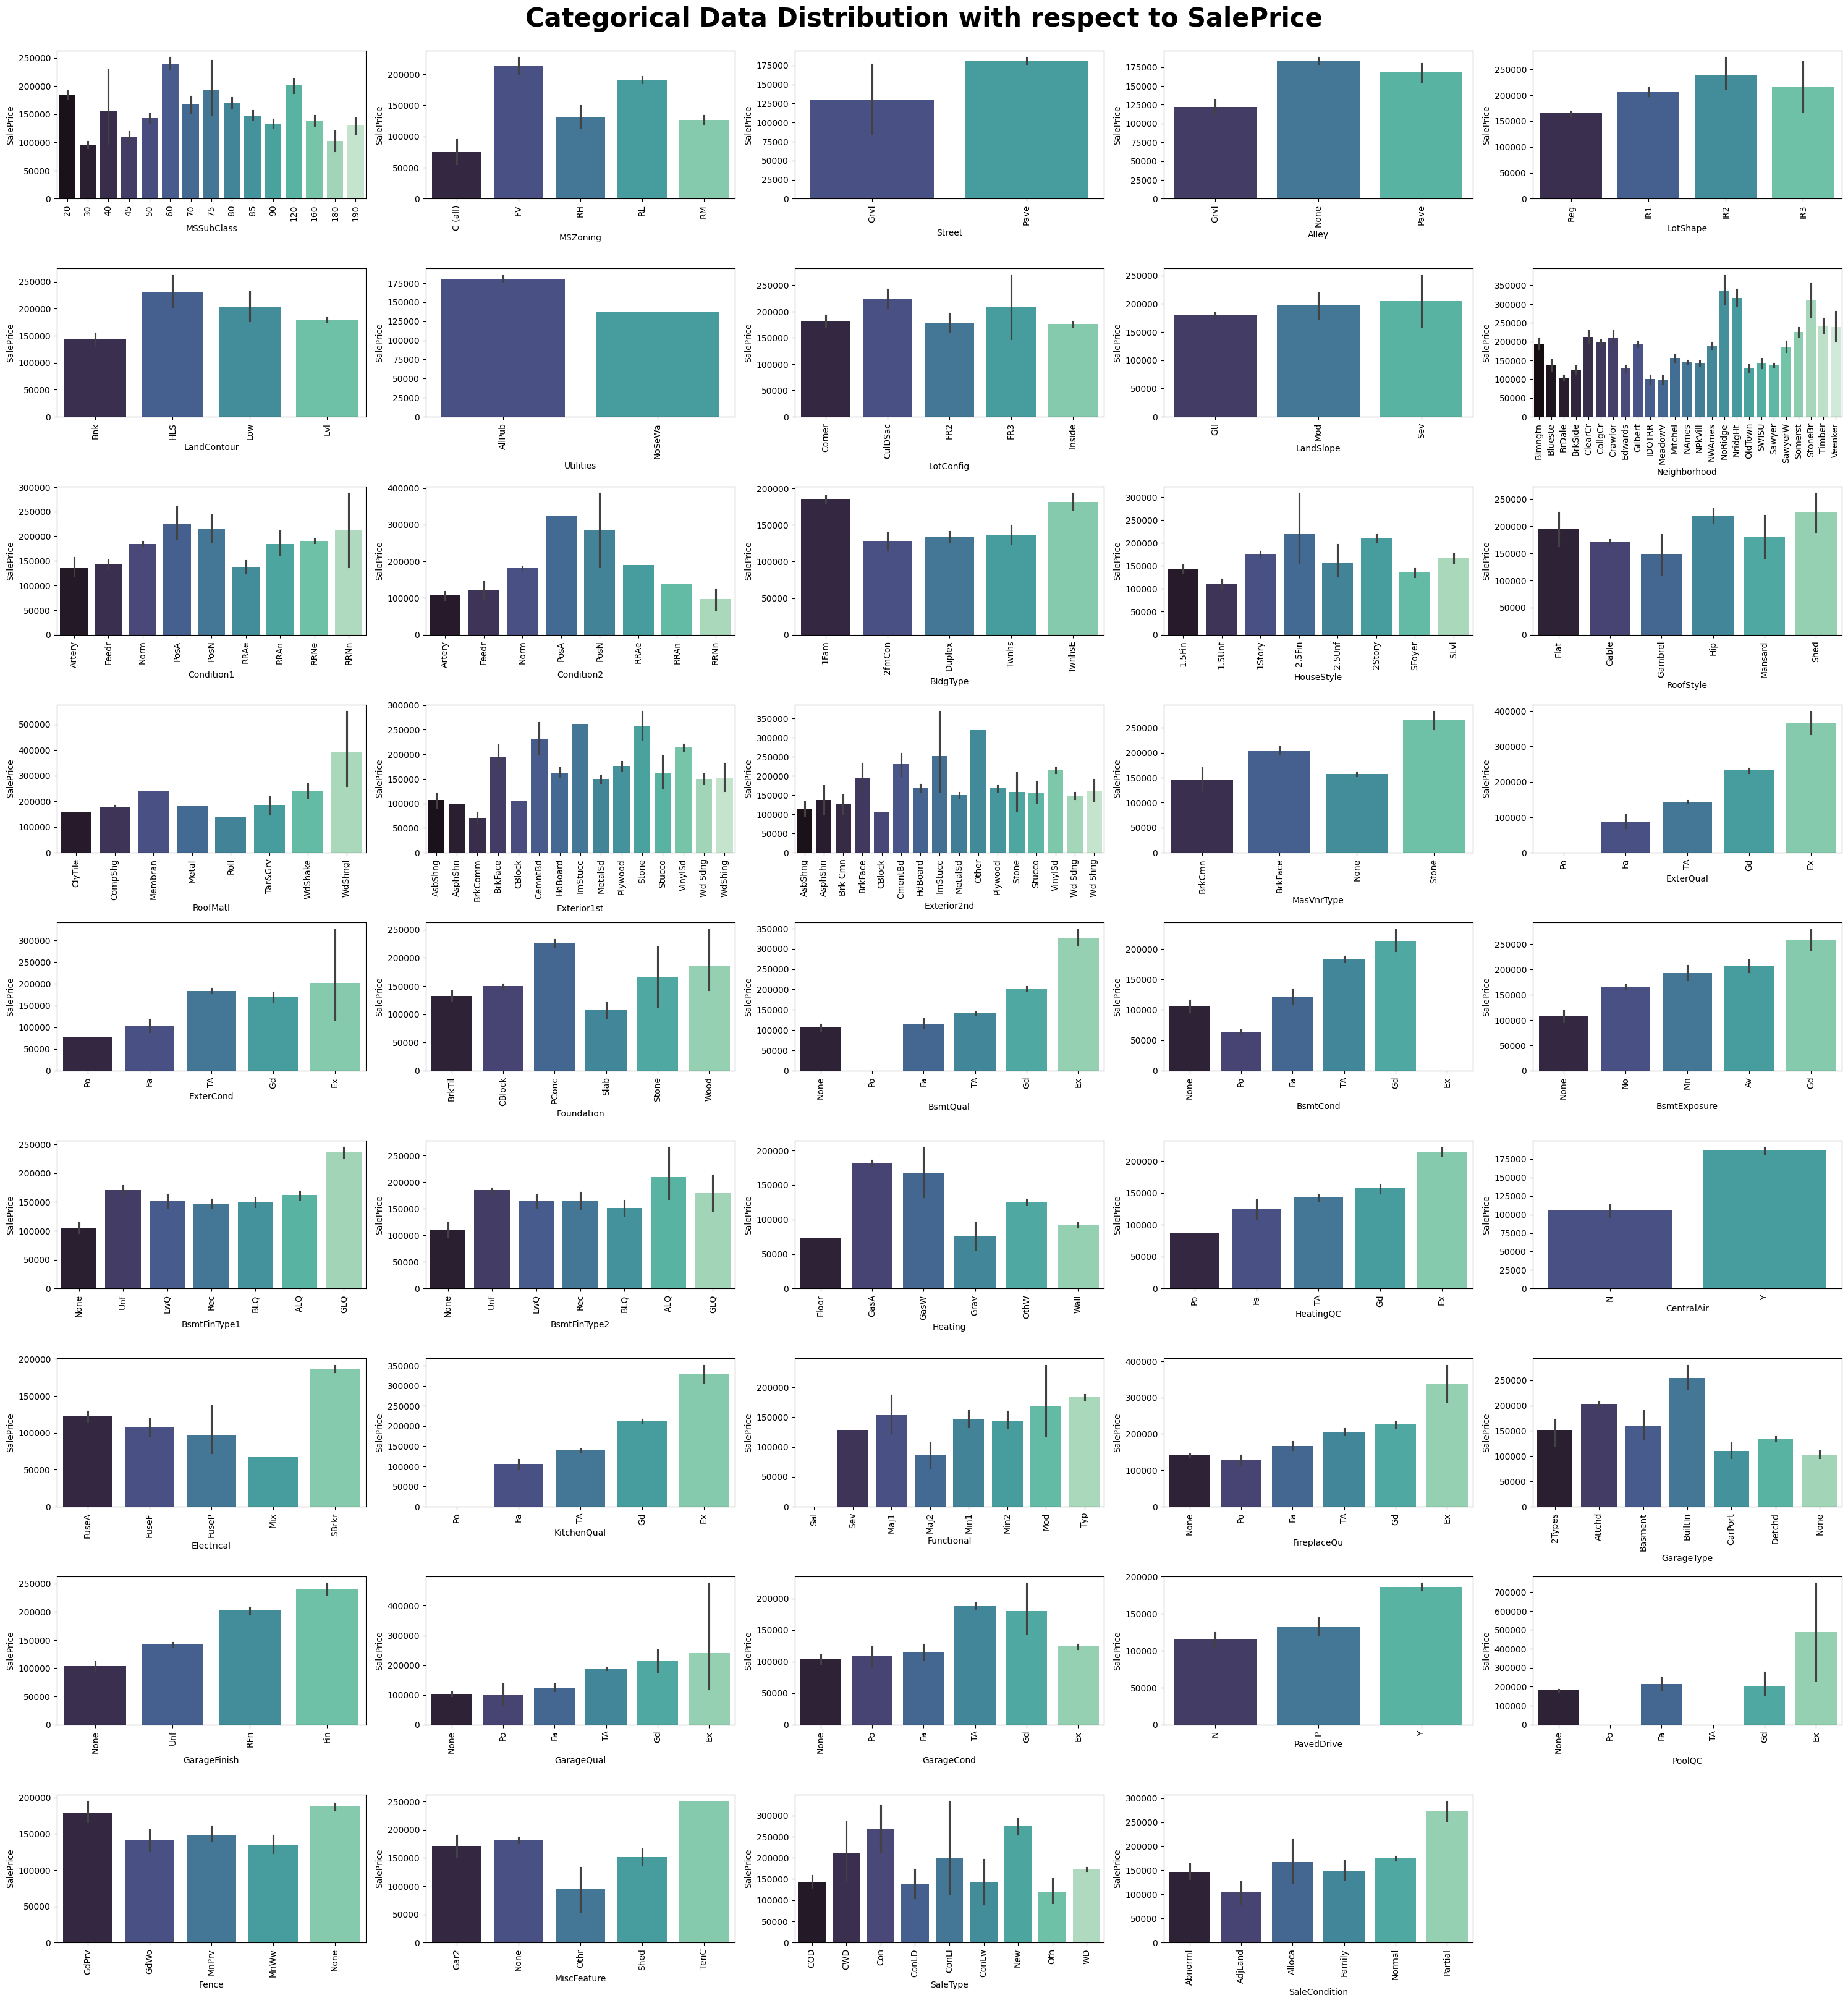

In [17]:
# Data Distribution in categorical Values with respect to SalePrice

plt.figure(figsize=(30,35))
plt.suptitle('Categorical Data Distribution with respect to SalePrice',fontsize=30, fontweight='bold', y=1)
for index, col in enumerate(categorical_features):
    plt.subplot(10, 5, index + 1)
    sns.barplot(data=df_train, x=col, y='SalePrice', palette='mako')
    plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

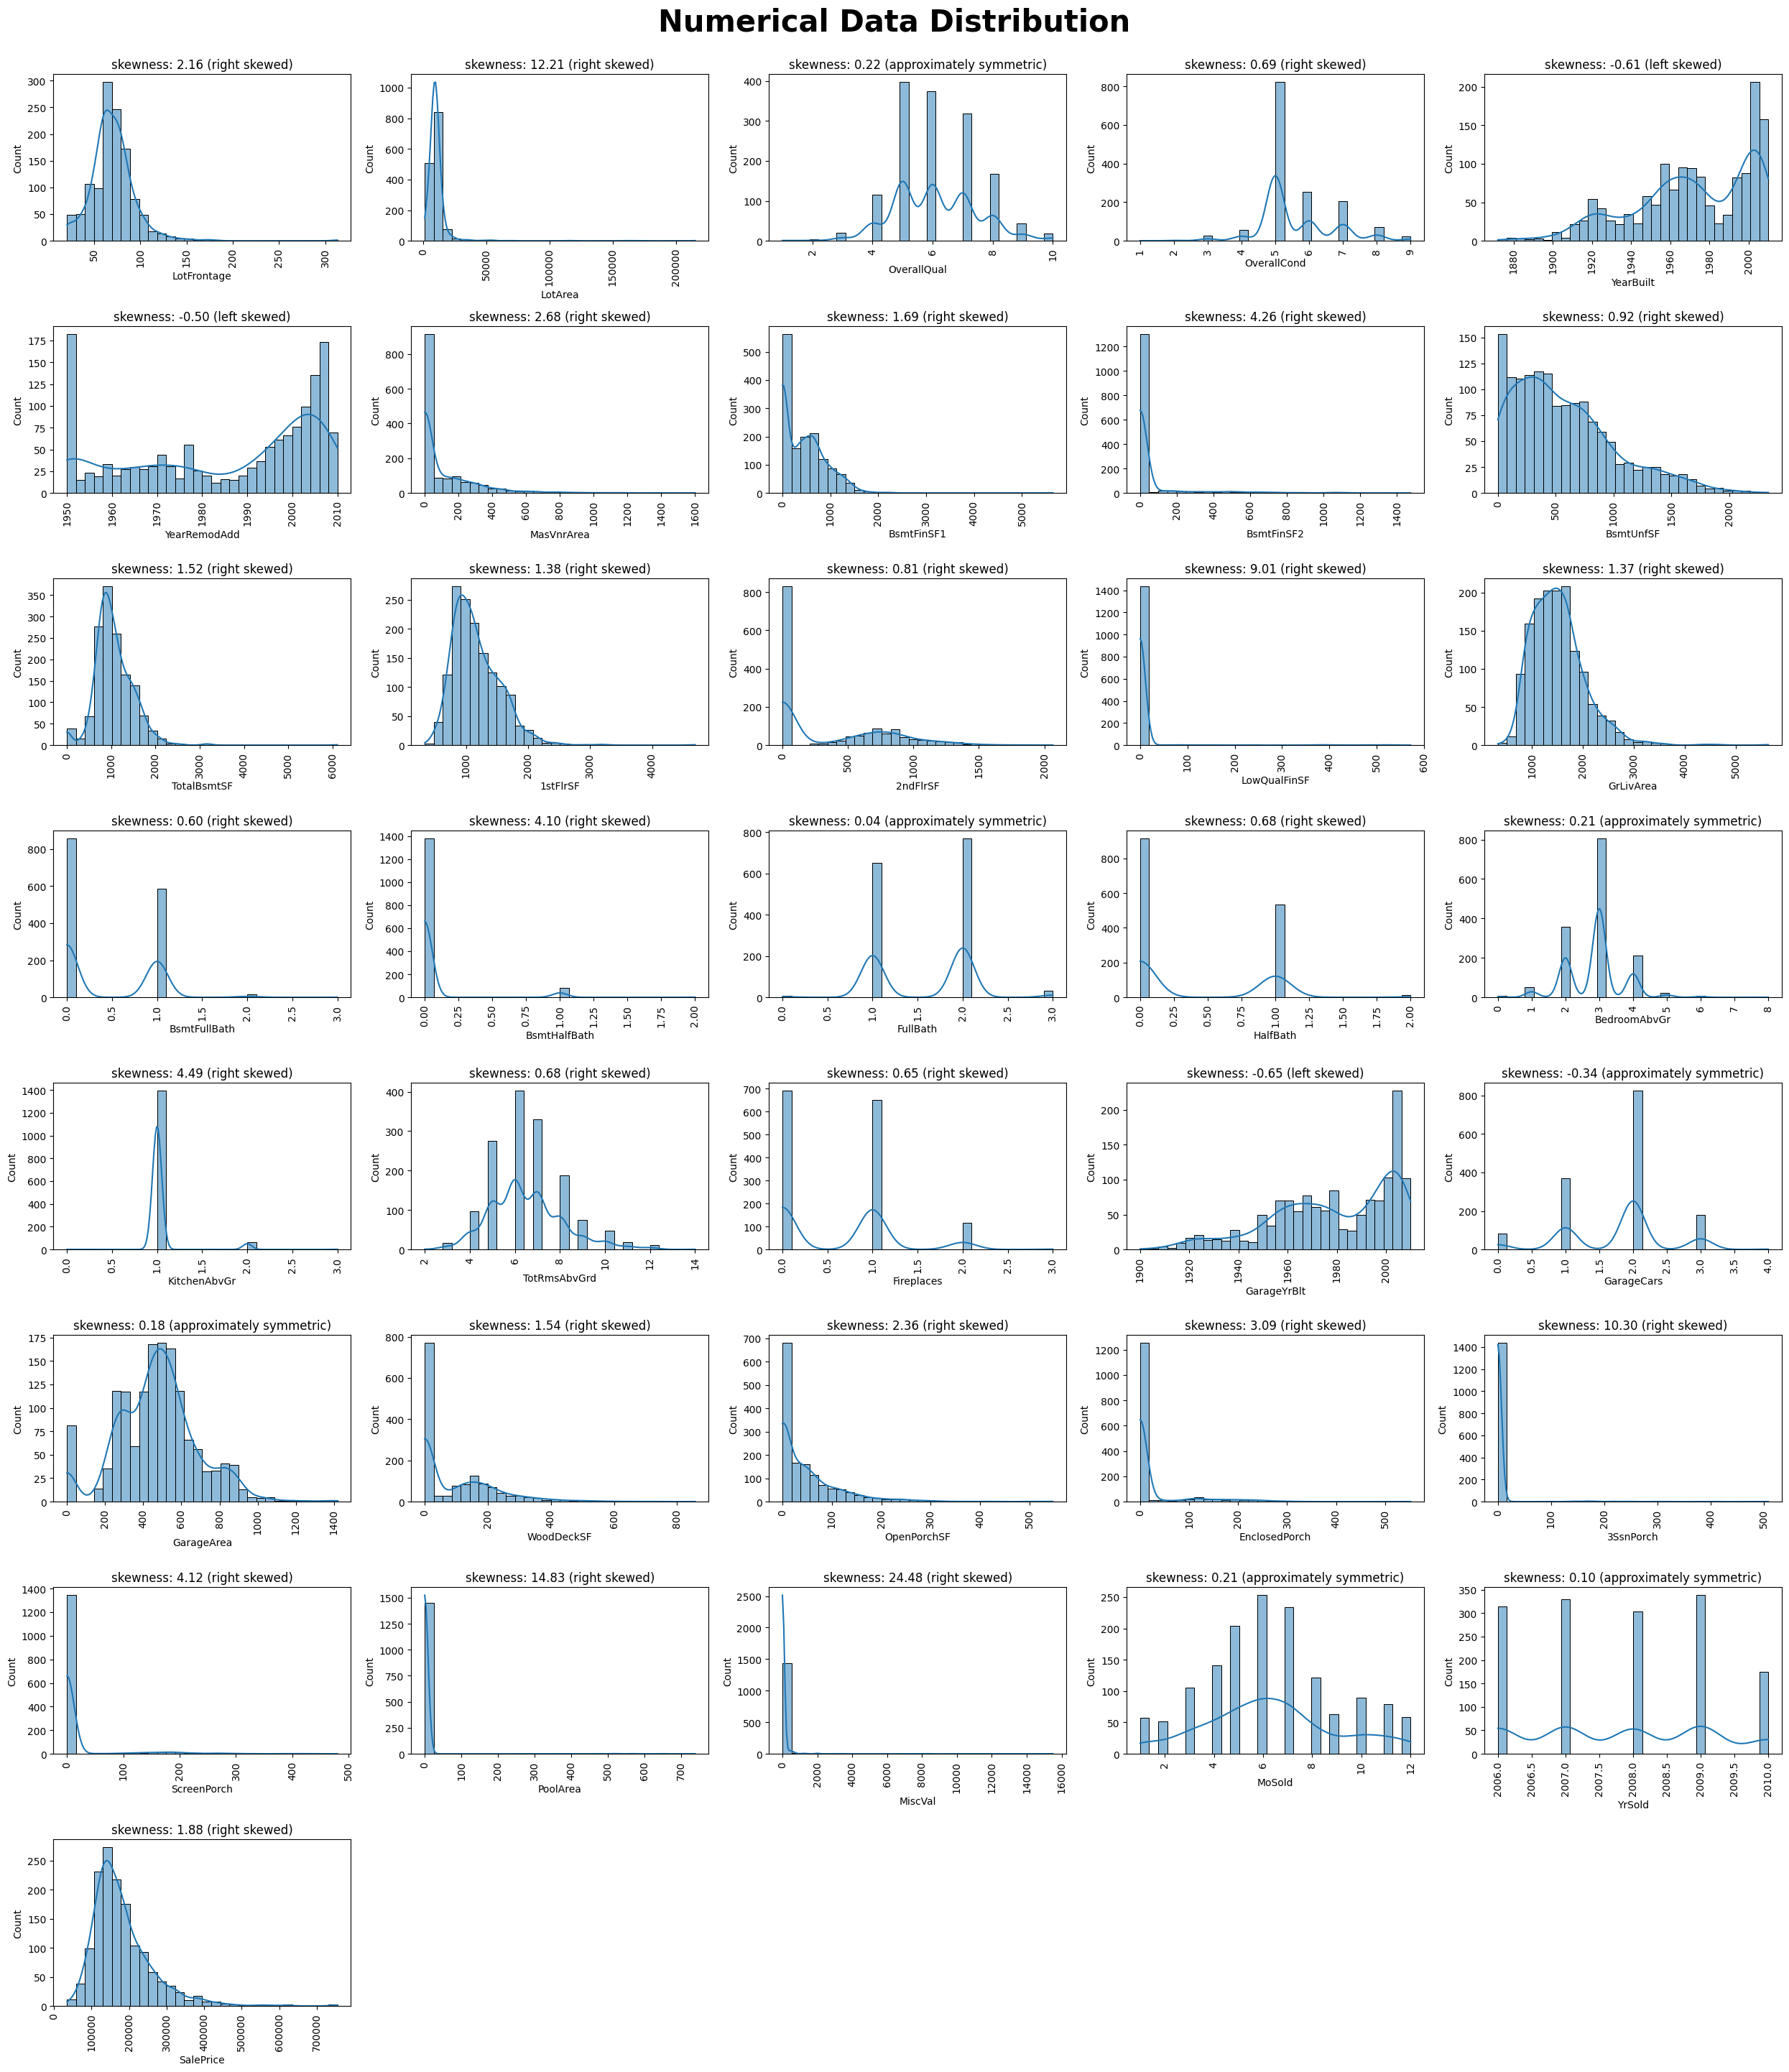

In [18]:
# Define Skewness:
def define_skewness(skew):
    if skew > 0.5:
        return 'right skewed'
    elif skew < -0.5:
        return 'left skewed'
    else:
        return 'approximately symmetric'

# Numerical Destribution

plt.figure(figsize=(25,35))
plt.suptitle('Numerical Data Distribution',fontsize=30, fontweight='bold', y=1)
for index, col in enumerate(numerical_features):
    plt.subplot(10, 5, index + 1)
    skewness = df_train[col].skew()
    sns.histplot(data=df_train, x=col, bins=30, kde=True)
    plt.xticks(rotation=90)
    plt.title(f'skewness: {skewness:.2f} ({define_skewness(skewness)})')

plt.tight_layout()
plt.show()

- Target : SalePrice is right skewed we may use log transform on it to fix it
- 'LotFrontage', 'BsmtFinSF1', 'LotArea', 'GrLivArea', '1stFlrSF', 'TotalBsmtSF', '2ndFlrSF', 'BsmtUnfSF', 'MasVnrArea', 'WoodDeckSF', 'OpenPorchSF' also are right skewed

<Axes: >

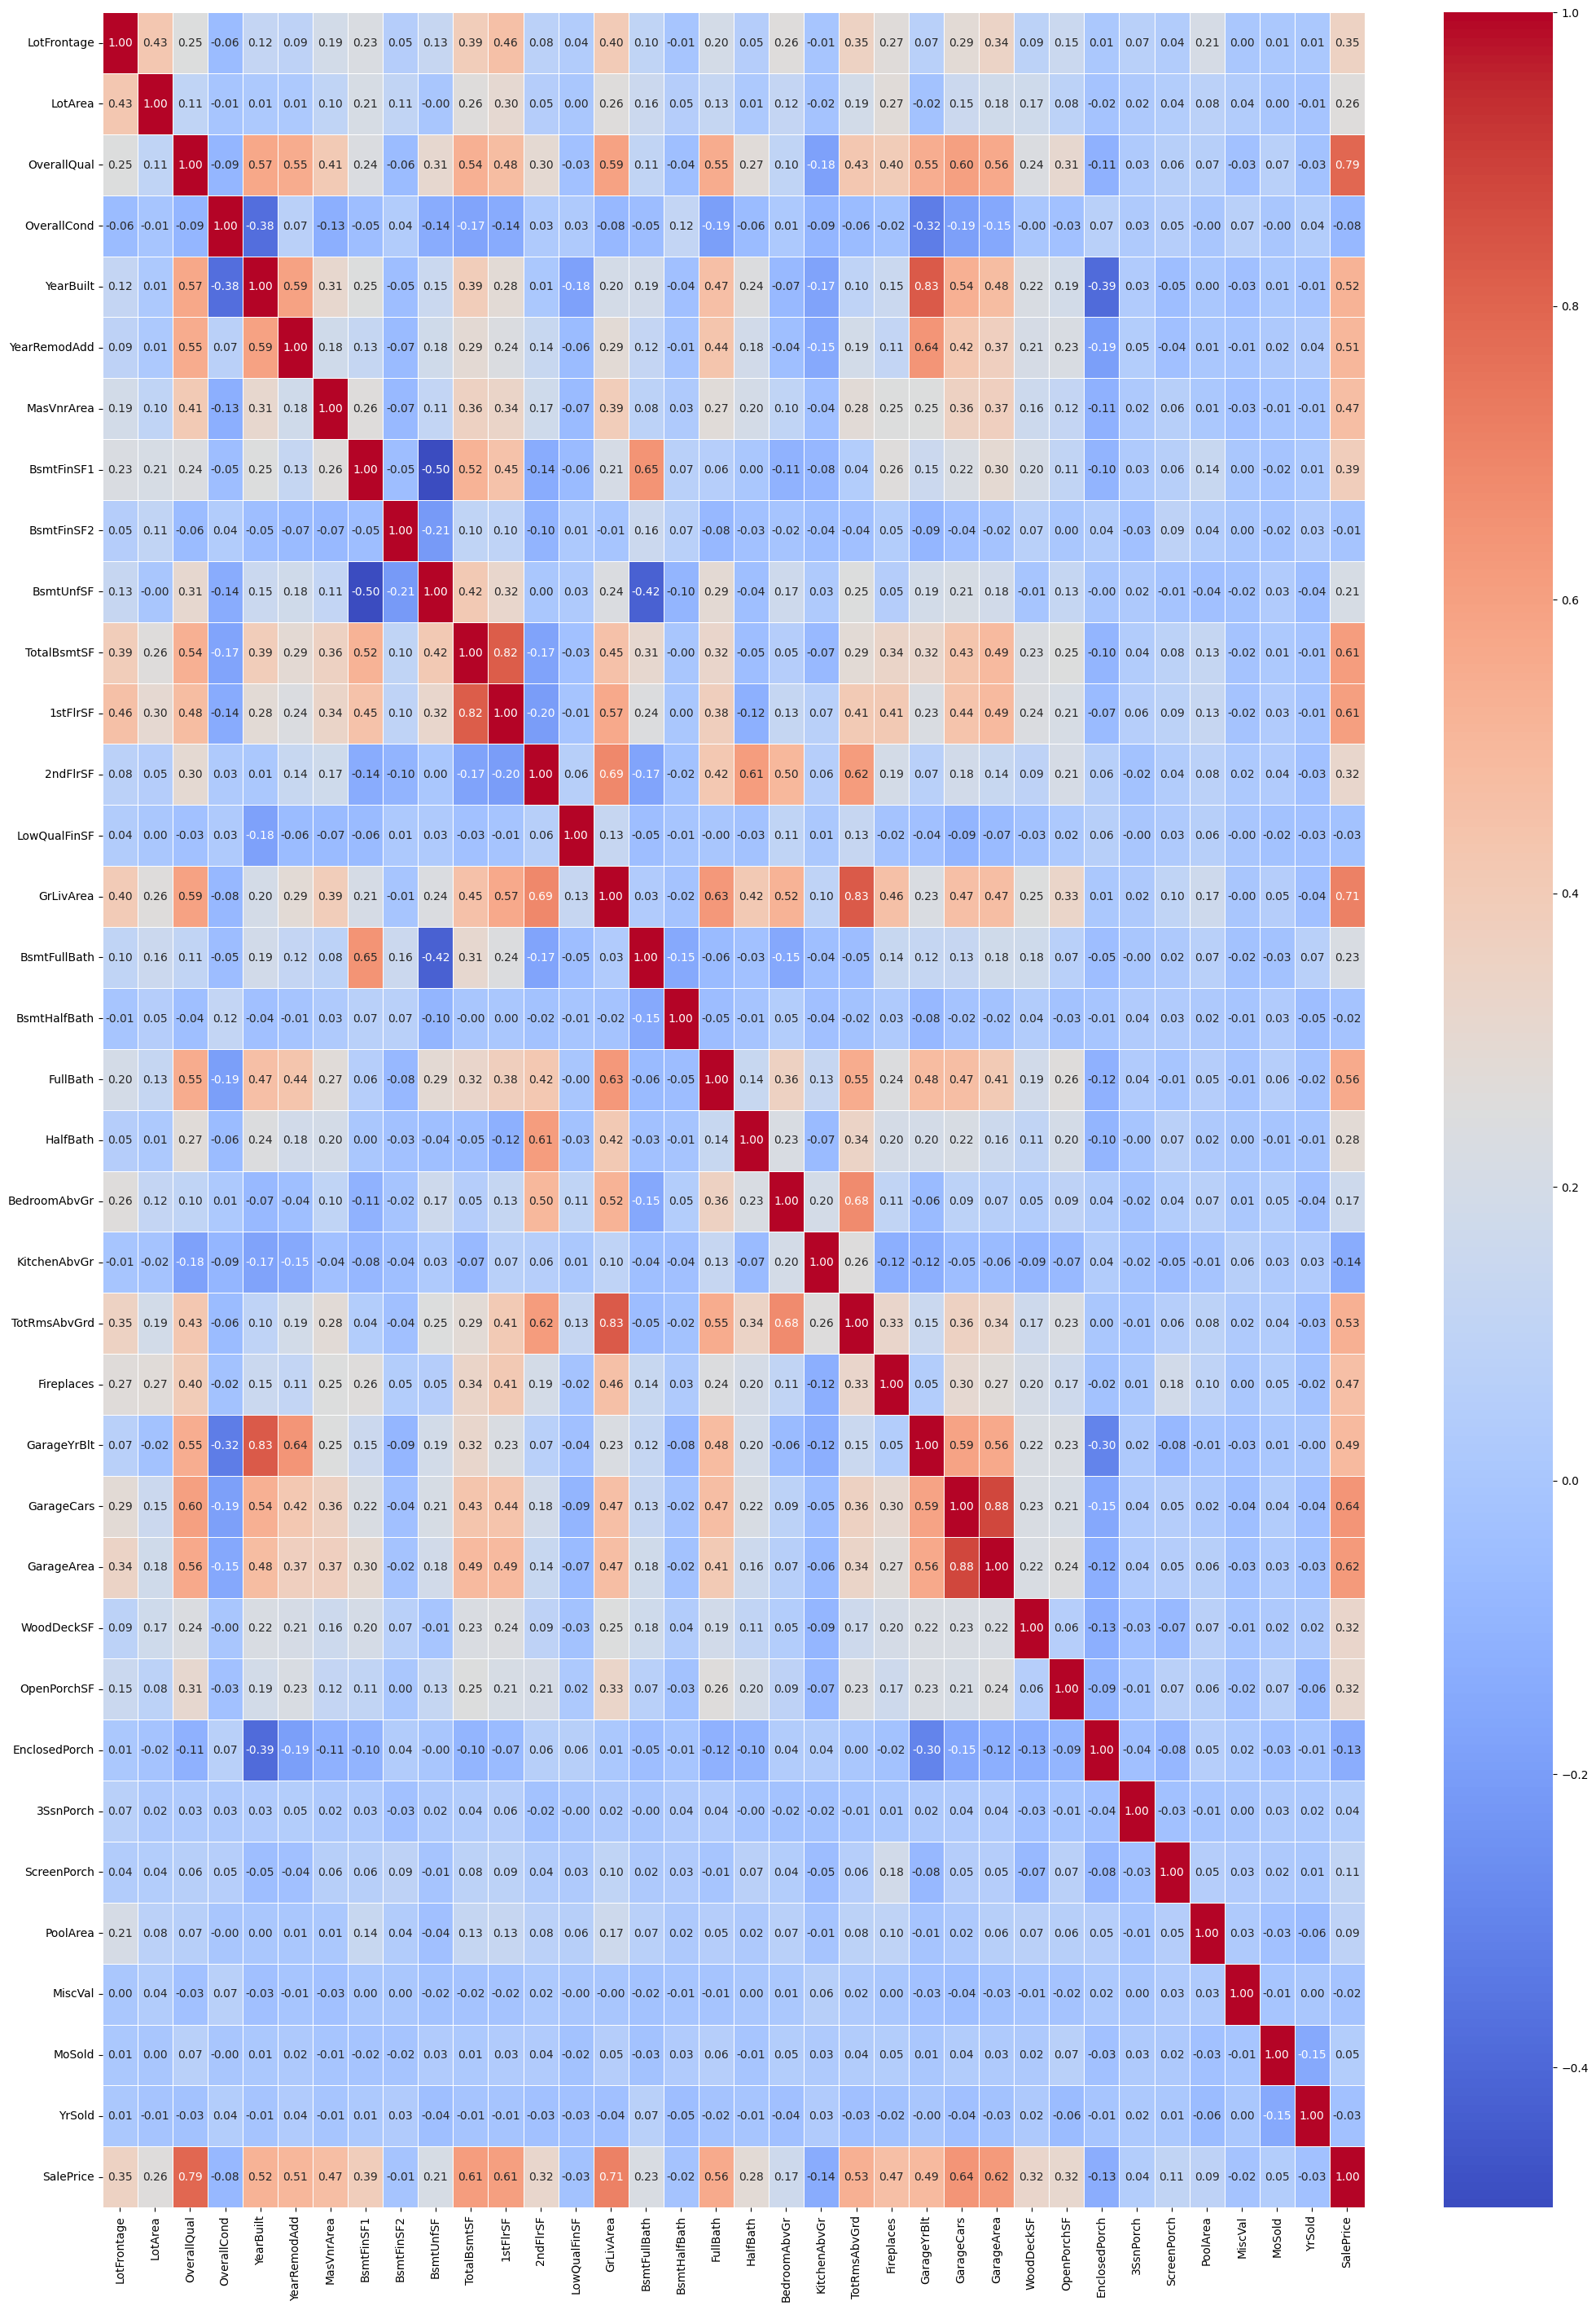

In [19]:
plt.figure(figsize=(25,35))
sns.heatmap(df_train[numerical_features].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

### We can notice that
- OverallQual (0.79), GrLivArea (0.71), GarageCars (0.64), GarageArea (0.62), TotalBsmtSF (0.61), 1stFlrSF (0.61) are the highest correlated features to our target

- We can see that there are high correlation between **(GarageCars, GarageArea, 0.882)**, **(GrLivArea, TotRmsAbvGrd, 0.825)**, **(TotalBsmtSF, 1stFlrSF, 0.820)**, **(YearBuilt, GarageYrBlt, 0.826)** which should be investegated later when building the model to prevent multicoolinearity

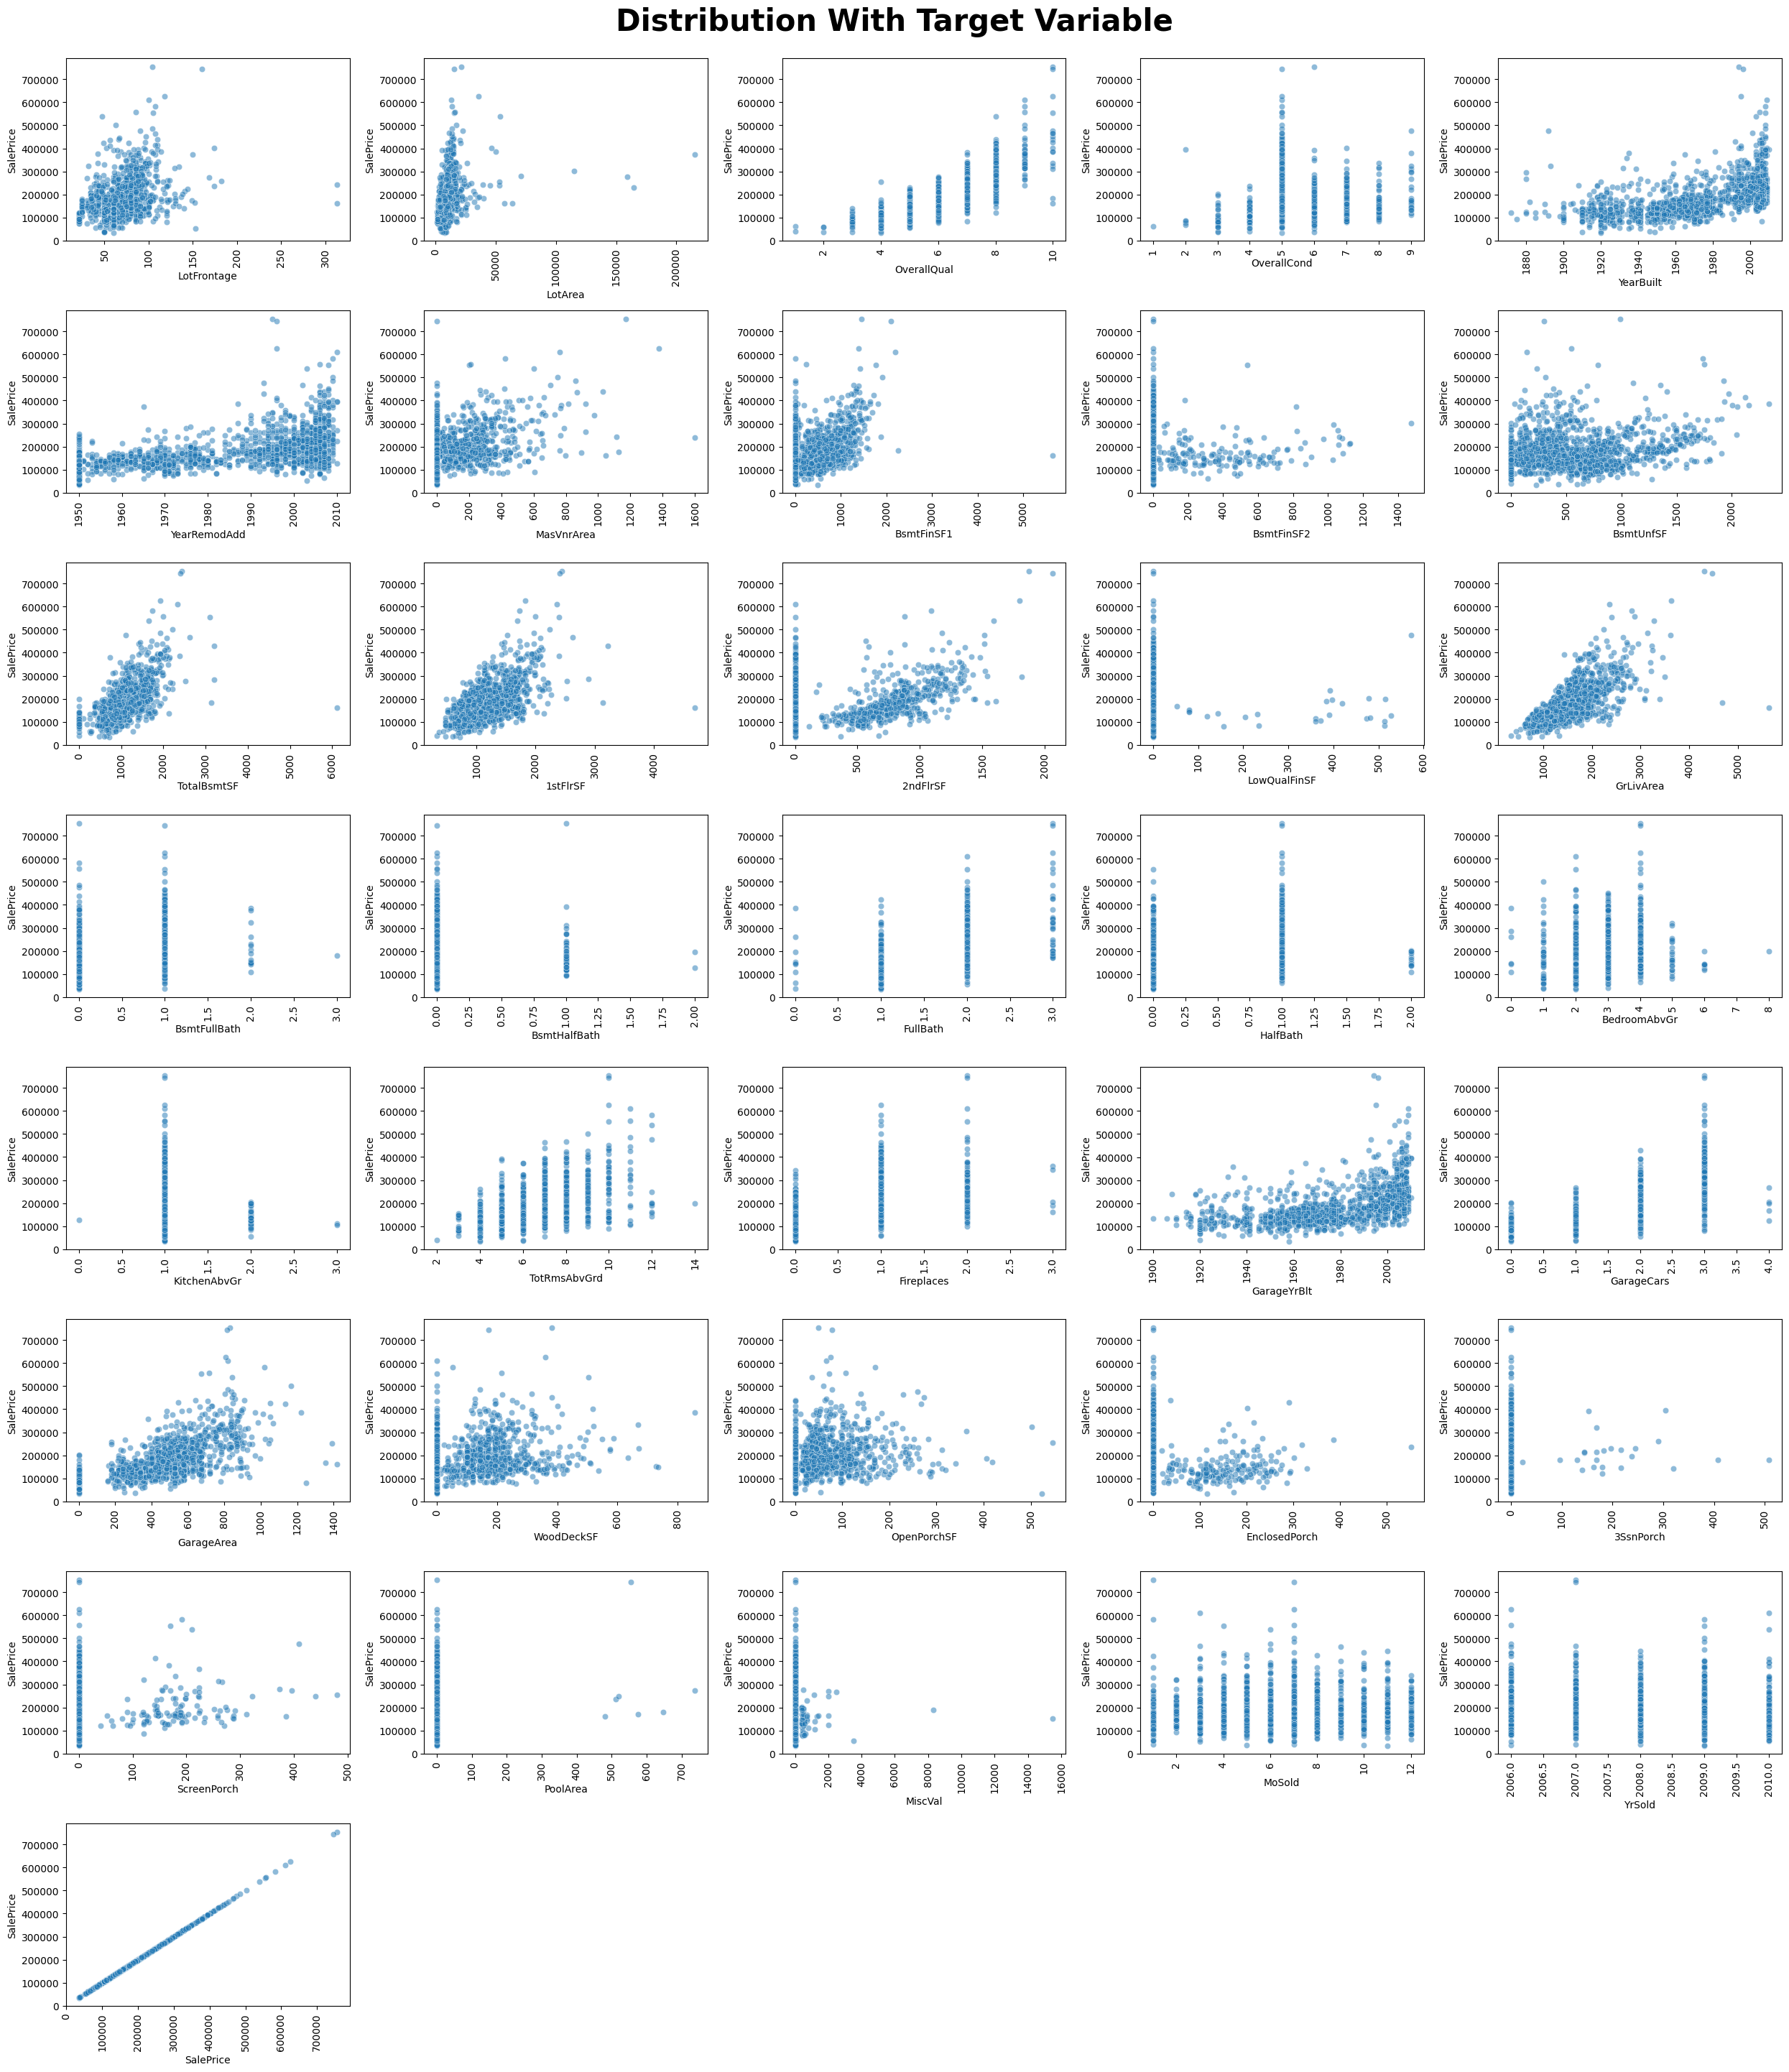

In [20]:
plt.figure(figsize=(25,35))
plt.suptitle('Distribution With Target Variable',fontsize=30, fontweight='bold', y=1)
for index, col in enumerate(numerical_features):
    plt.subplot(10, 5, index + 1)
    sns.scatterplot(data=df_train, x=col, y='SalePrice', alpha=0.5)
    plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

- We can detect some Relations between the features and the target
- There are 2 upnormal values in the GrLivArea the are > 4000 and price less than 200000 which should be removed

# 3- Preprocessing

In [21]:
skewed_features = ['LotFrontage', 'BsmtFinSF1', 'LotArea', 'GrLivArea', '1stFlrSF', 'TotalBsmtSF', '2ndFlrSF', 'BsmtUnfSF', 'MasVnrArea', 'WoodDeckSF', 'OpenPorchSF']
other_numerical_features = numerical_features.drop(skewed_features).drop('SalePrice')
ordinal_features_keys = list(ordinal_features.keys())
ordinal_features_values = list(ordinal_features.values())

In [22]:
# Droping outliers in GrLivArea scatter plots with SalePrice
outliers = df_train[(df_train['GrLivArea'] > 4000) & (df_train['SalePrice'] < 200000)].index
df_train = df_train.drop(outliers)

In [23]:
X = df_train.drop(columns=['SalePrice'])
y = np.log1p(df_train['SalePrice'])

In [24]:
# Categorical Pipeline
nominal_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('encode', OneHotEncoder(handle_unknown='ignore'))
])

ordinal_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('encode', OrdinalEncoder(categories=ordinal_features_values, handle_unknown='use_encoded_value', unknown_value=-1))
])

In [25]:
# Numerical Pipeline
skewed_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('log',    FunctionTransformer(np.log1p, feature_names_out='one-to-one')),
    ('scale',  StandardScaler())
])

other_numerical_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale',  StandardScaler())
])

In [26]:
# Perprocessing Pipeline
preprocessor = ColumnTransformer([
    ('skewed_features',          skewed_pipeline,           skewed_features),
    ('other_numerical_features', other_numerical_pipeline,  other_numerical_features),
    ('ordinal_features',         ordinal_pipeline,          ordinal_features_keys),
    ('nominal_features',         nominal_pipeline,          nominal_features)
])

In [27]:
# BaseEstimator : lets sklearn clone it inside cross_val_score/GridSearchCV.
# TransformerMixin : lets sklearn use fit_transform method on it.
class LotFrontageImputer(BaseEstimator, TransformerMixin):
    """Impute missing values in LotFrontage column based on Neighborhood."""

    def fit(self, X, y=None):
        self.medians_ = X.groupby('Neighborhood')['LotFrontage'].median()
        self.global_ = X['LotFrontage'].median()
        return self

    def transform(self, X):
        X = X.copy()
        fill = X['Neighborhood'].map(self.medians_).fillna(self.global_)
        X['LotFrontage'] = X['LotFrontage'].fillna(fill)
        return X

In [28]:
# Model Pipeline

kf = KFold(n_splits=5, shuffle=True, random_state=42)

def make_pipe(model):
    return Pipeline([
        ('lot_frontage_imputer', LotFrontageImputer()),
        ('preprocessor', preprocessor),
        ('model', model)
    ])

## 4- Modeling

In [29]:
models = {
    'Linear':  LinearRegression(),
    'Ridge':   Ridge(alpha=10),
    'Lasso':   Lasso(alpha=0.0005, max_iter=10000),
    'SVR':     SVR(C=10, epsilon=0.01, gamma='scale'),
    'KNN':     KNeighborsRegressor(n_neighbors=10, weights='distance'),
    'RF':      RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
    'GBR':     GradientBoostingRegressor(n_estimators=500, learning_rate=0.05,
                                         max_depth=3, subsample=0.8, random_state=42),
    'XGB':     XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=3,
                            subsample=0.8, colsample_bytree=0.8, random_state=42),
}

results = {}
for name, model in models.items():
    scores = -cross_val_score(make_pipe(model), X, y, cv=kf,
                              scoring='neg_root_mean_squared_error', n_jobs=-1)
    results[name] = (scores.mean(), scores.std())
    print(f'{name:7s} {scores.mean():.4f} ± {scores.std():.4f}')

pd.DataFrame(results, index=['mean', 'std']).T.sort_values('mean')

/var/folders/gk/7214bb9n5fz91t1cpgb_yvb40000gn/T/ipykernel_50664/2174618686.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/var/folders/gk/7214bb9n5fz91t1cpgb_yvb40000gn/T/ipykernel_50664/2174618686.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/var/folders/gk/7214bb9n5fz91t1cpgb_yvb40000gn/T/ipykernel_50664/2174618686.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/var/folders/gk/7214bb9n5fz91t1cpgb_yvb40000gn

Linear  902412233.9030 ± 1592314941.6108


/var/folders/gk/7214bb9n5fz91t1cpgb_yvb40000gn/T/ipykernel_50664/2174618686.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/var/folders/gk/7214bb9n5fz91t1cpgb_yvb40000gn/T/ipykernel_50664/2174618686.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/var/folders/gk/7214bb9n5fz91t1cpgb_yvb40000gn/T/ipykernel_50664/2174618686.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/var/folders/gk/7214bb9n5fz91t1cpgb_yvb40000gn

Ridge   0.1158 ± 0.0077


/var/folders/gk/7214bb9n5fz91t1cpgb_yvb40000gn/T/ipykernel_50664/2174618686.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/var/folders/gk/7214bb9n5fz91t1cpgb_yvb40000gn/T/ipykernel_50664/2174618686.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/var/folders/gk/7214bb9n5fz91t1cpgb_yvb40000gn/T/ipykernel_50664/2174618686.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/var/folders/gk/7214bb9n5fz91t1cpgb_yvb40000gn

...

/var/folders/gk/7214bb9n5fz91t1cpgb_yvb40000gn/T/ipykernel_50664/2174618686.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/var/folders/gk/7214bb9n5fz91t1cpgb_yvb40000gn/T/ipykernel_50664/2174618686.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/var/folders/gk/7214bb9n5fz91t1cpgb_yvb40000gn/T/ipykernel_50664/2174618686.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/var/folders/gk/7214bb9n5fz91t1cpgb_yvb40000gn

GBR     0.1159 ± 0.0081


/var/folders/gk/7214bb9n5fz91t1cpgb_yvb40000gn/T/ipykernel_50664/2174618686.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/var/folders/gk/7214bb9n5fz91t1cpgb_yvb40000gn/T/ipykernel_50664/2174618686.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/var/folders/gk/7214bb9n5fz91t1cpgb_yvb40000gn/T/ipykernel_50664/2174618686.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/var/folders/gk/7214bb9n5fz91t1cpgb_yvb40000gn

XGB     0.1163 ± 0.0076


,mean,std
Lasso,1.138642e-01,7.030265e-03
Ridge,1.158113e-01,7.685204e-03
GBR,1.158700e-01,8.143201e-03
XGB,1.163181e-01,7.556094e-03
SVR,1.301320e-01,1.005481e-02
RF,1.381278e-01,8.026912e-03
KNN,1.701117e-01,1.053141e-02
Linear,9.024122e+08,1.592315e+09


- Ridge, Lasso, GBR, XGB are the best models so we will try to hyper tune them

In [30]:
def grid_search(model, param_grid):
    grid = GridSearchCV(
        make_pipe(model),
        param_grid,
        cv=kf,
        scoring='neg_root_mean_squared_error',
    ).fit(X, y)
    print(f"{model.__class__.__name__} Best Parameters: {grid.best_params_}")
    print(f"{model.__class__.__name__} Best Score: {-grid.best_score_:.4f}")
    return grid

In [31]:
lasso_param_grid = {
    'model__alpha': [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.05],
    'model__max_iter': [10000, 20000, 30000]
}

lasso_grid = grid_search(Lasso(), lasso_param_grid)

Lasso Best Parameters: {'model__alpha': 0.0005, 'model__max_iter': 10000}
Lasso Best Score: 0.1139


In [32]:
ridge_param_grid = {
    'model__alpha': [0.1, 1, 10, 100, 200, 300, 400, 500],
    'model__max_iter': [10000, 20000, 30000]
}

ridge_grid = grid_search(Ridge(), ridge_param_grid)

Ridge Best Parameters: {'model__alpha': 10, 'model__max_iter': 10000}
Ridge Best Score: 0.1158


In [33]:
gbr_params = {
    'model__n_estimators':     [500, 1000, 1500],
    'model__learning_rate':    [0.01, 0.02, 0.03, 0.05],
    'model__max_depth':        [2, 3, 4],
    'model__min_samples_leaf': [5, 10, 15, 20],
    'model__max_features':     ['sqrt', 0.3, 0.5],
    'model__subsample':        [0.6, 0.7, 0.8, 0.9],
    'model__loss':             ['squared_error', 'huber'],
}

gbr_grid = RandomizedSearchCV(
        make_pipe(GradientBoostingRegressor(random_state=42)),
        gbr_params,
        n_iter=30, 
        cv=kf, 
        scoring='neg_root_mean_squared_error', 
        n_jobs=-1, 
        random_state=42
).fit(X, y)

print(f"GBR Best Parameters: {gbr_grid.best_params_}")
print(f"GBR Best Score: {-gbr_grid.best_score_:.4f}")

/var/folders/gk/7214bb9n5fz91t1cpgb_yvb40000gn/T/ipykernel_50664/2174618686.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/var/folders/gk/7214bb9n5fz91t1cpgb_yvb40000gn/T/ipykernel_50664/2174618686.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/var/folders/gk/7214bb9n5fz91t1cpgb_yvb40000gn/T/ipykernel_50664/2174618686.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/var/folders/gk/7214bb9n5fz91t1cpgb_yvb40000gn

GBR Best Parameters: {'model__subsample': 0.7, 'model__n_estimators': 1500, 'model__min_samples_leaf': 5, 'model__max_features': 'sqrt', 'model__max_depth': 2, 'model__loss': 'huber', 'model__learning_rate': 0.03}
GBR Best Score: 0.1115


In [34]:
xgb_params = {
    'model__n_estimators':     [500, 1000, 1500],
    'model__learning_rate':    [0.01, 0.02, 0.03, 0.05],
    'model__max_depth':        [2, 3, 4],
    'model__min_child_weight': [1, 3, 5],
    'model__subsample':        [0.6, 0.7, 0.8, 0.9],
    'model__colsample_bytree': [0.3, 0.5, 0.7],
    'model__reg_alpha':        [0, 0.01, 0.1],
    'model__reg_lambda':       [0.5, 1, 3],
}

xgb_grid = RandomizedSearchCV(
    make_pipe(XGBRegressor(random_state=42)),
    xgb_params, 
    n_iter=30, 
    cv=kf, 
    scoring='neg_root_mean_squared_error', 
    n_jobs=-1, 
    random_state=42
).fit(X, y)

print(f"XGB Best Parameters: {xgb_grid.best_params_}")
print(f"XGB Best Score: {-xgb_grid.best_score_:.4f}")


/var/folders/gk/7214bb9n5fz91t1cpgb_yvb40000gn/T/ipykernel_50664/2174618686.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/var/folders/gk/7214bb9n5fz91t1cpgb_yvb40000gn/T/ipykernel_50664/2174618686.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/var/folders/gk/7214bb9n5fz91t1cpgb_yvb40000gn/T/ipykernel_50664/2174618686.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/var/folders/gk/7214bb9n5fz91t1cpgb_yvb40000gn

XGB Best Parameters: {'model__subsample': 0.7, 'model__reg_lambda': 3, 'model__reg_alpha': 0.01, 'model__n_estimators': 1000, 'model__min_child_weight': 3, 'model__max_depth': 3, 'model__learning_rate': 0.03, 'model__colsample_bytree': 0.3}
XGB Best Score: 0.1119


In [35]:
pd.DataFrame(
    {'Best Score': [-lasso_grid.best_score_, -ridge_grid.best_score_, -gbr_grid.best_score_, -xgb_grid.best_score_]}, index=['Lasso', 'Ridge', 'GBR', 'XGB']).sort_values('Best Score')

,Best Score
GBR,0.111526
XGB,0.111907
Lasso,0.113864
Ridge,0.115811


In [36]:
from sklearn.ensemble import VotingRegressor

ens = VotingRegressor([
    ('lasso', lasso_grid.best_estimator_),
    ('gbr',   gbr_grid.best_estimator_),
    ('xgb',   xgb_grid.best_estimator_),
])

s = -cross_val_score(ens, X, y, cv=kf, scoring='neg_root_mean_squared_error')
print(f'Ensemble: {s.mean():.4f} ± {s.std():.4f}')

Ensemble: 0.1078 ± 0.0082


- After Hyper Paramaters Tuning The ensembling between models gives us the best RMSE

In [37]:
ens.fit(X, y)

VotingRegressor(estimators=[('lasso',
                             Pipeline(steps=[('lot_frontage_imputer',
                                              LotFrontageImputer()),
                                             ('preprocessor',
                                              ColumnTransformer(transformers=[('skewed_features',
                                                                               Pipeline(steps=[('impute',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('log',
                                                                                                FunctionTransformer(feature_names_out='one-to-one',
                                                                                                                    func=<ufunc 'log1p'>)),
                                                                                               ('scale',
                                                                                                StandardScaler())]),
                                                                               ['LotFrontage',...
                                                           feature_weights=None,
                                                           gamma=None,
                                                           grow_policy=None,
                                                           importance_type=None,
                                                           interaction_constraints=None,
                                                           learning_rate=0.03,
                                                           max_bin=None,
                                                           max_cat_threshold=None,
                                                           max_cat_to_onehot=None,
                                                           max_delta_step=None,
                                                           max_depth=3,
                                                           max_leaves=None,
                                                           min_child_weight=3,
                                                           missing=nan,
                                                           monotone_constraints=None,
                                                           multi_strategy=None,
                                                           n_estimators=1000,
                                                           n_jobs=None,
                                                           num_parallel_tree=None, ...))]))])

In [38]:
y_pred = np.expm1(ens.predict(df_test))

submission = pd.DataFrame({
    'Id': df_test_id,
    'SalePrice': y_pred
})

submission.to_csv('submission.csv', index=False)

submission

,Id,SalePrice
0,1461,122755.043522
1,1462,155669.123329
2,1463,185448.352420
3,1464,196520.879946
4,1465,195873.978420
...,...,...
1454,2915,83932.557357
1455,2916,81809.072495
1456,2917,162797.895974
1457,2918,121496.977722
